---
title: "Lab 6"
format: 
    html:
        embed-resources: true
code-fold: true
echo: true
---

In [1]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_selector, ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, root_mean_squared_error

In [2]:
myData = pd.read_csv("Hitters.csv")
myData.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [3]:
myData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      322 non-null    int64  
 1   Hits       322 non-null    int64  
 2   HmRun      322 non-null    int64  
 3   Runs       322 non-null    int64  
 4   RBI        322 non-null    int64  
 5   Walks      322 non-null    int64  
 6   Years      322 non-null    int64  
 7   CAtBat     322 non-null    int64  
 8   CHits      322 non-null    int64  
 9   CHmRun     322 non-null    int64  
 10  CRuns      322 non-null    int64  
 11  CRBI       322 non-null    int64  
 12  CWalks     322 non-null    int64  
 13  League     322 non-null    object 
 14  Division   322 non-null    object 
 15  PutOuts    322 non-null    int64  
 16  Assists    322 non-null    int64  
 17  Errors     322 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  322 non-null    object 
dtypes: float64

In [4]:
myData = myData.dropna()

## Part 1: Different Model Specs

Regression Without Regularization

In [5]:
X = myData.drop(["Salary"], axis = 1)
y = myData["Salary"]

In [6]:
ct = ColumnTransformer(
  [
    ("dummify",
    OneHotEncoder(sparse_output = False, handle_unknown='ignore'),
    make_column_selector(dtype_include=object)),
    ("standardize",
    StandardScaler(),
    make_column_selector(dtype_include=np.number))
  ],
  remainder = "passthrough"
).set_output(transform="pandas")

In [7]:
lr_pipeline_1 = Pipeline(
  [("preprocessing", ct),
  ("linear_regression", LinearRegression())]
)

In [8]:
lr_pipeline_1_fitted = lr_pipeline_1.fit(X, y)

lr_pipeline_1_fitted

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7c5250881580>),
                                                 ('standardize',
                                                  StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7c5250881bb0>)])),
                ('linear_regression', LinearRegression())])

In [9]:
coef_compare = pd.DataFrame()
coef_compare["Column Names"] = lr_pipeline_1_fitted.named_steps['preprocessing'].get_feature_names_out()

coef_compare["lr coeff"] = lr_pipeline_1_fitted.named_steps['linear_regression'].coef_
coef_compare

,Column Names,lr coeff
0,dummify__League_A,-31.299712
1,dummify__League_N,31.299712
2,dummify__Division_E,58.424623
3,dummify__Division_W,-58.424623
4,dummify__NewLeague_A,12.381163
5,dummify__NewLeague_N,-12.381163
6,standardize__AtBat,-291.094556
7,standardize__Hits,337.830479
8,standardize__HmRun,37.853837
9,standardize__Runs,-60.572479


The highest positive coefficient belongs to CRuns and is 480.75. The most negative coefficient belongs to CAtBat and is -391.04.

In [10]:
cross_val_score(lr_pipeline_1, X, y, cv = 5, scoring = 'neg_mean_squared_error')

array([ -76408.91409134, -129937.76968228,  -79976.48830477,
       -204818.01839674, -114540.36111572])

Ridge Regression

In [11]:
from sklearn.model_selection import GridSearchCV

ridge_pipeline = Pipeline(
  [("preprocessing", ct),
  ("ridge_regression", Ridge())]
).set_output(transform="pandas")

alphas = {'ridge_regression__alpha': np.array([0.01, 0.1, 1, 10, 100])}
gscv = GridSearchCV(ridge_pipeline, param_grid=alphas, cv = 5, scoring='neg_mean_squared_error')

In [12]:
gscv_fitted = gscv.fit(X, y)

gscv_fitted.cv_results_

{'mean_fit_time': array([0.01349607, 0.01192923, 0.01161008, 0.01129742, 0.01106005]),
 'std_fit_time': array([0.00464849, 0.00092057, 0.00107893, 0.00079753, 0.00018796]),
 'mean_score_time': array([0.00777874, 0.00761685, 0.00786886, 0.00722222, 0.00787716]),
 'std_score_time': array([0.00087582, 0.00076137, 0.00083554, 0.0003814 , 0.00167137]),
 'param_ridge_regression__alpha': masked_array(data=[0.01, 0.1, 1.0, 10.0, 100.0],
              mask=[False, False, False, False, False],
        fill_value=1e+20),
 'params': [{'ridge_regression__alpha': np.float64(0.01)},
  {'ridge_regression__alpha': np.float64(0.1)},
  {'ridge_regression__alpha': np.float64(1.0)},
  {'ridge_regression__alpha': np.float64(10.0)},
  {'ridge_regression__alpha': np.float64(100.0)}],
 'split0_test_score': array([-76429.09986569, -76592.42606924, -76881.86322107, -68808.21931447,
        -54207.32108578]),
 'split1_test_score': array([-129928.28822833, -130013.47969564, -133524.06955313,
        -149555.580662

In [13]:
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)

df_cv_results_.sort_values(by='rank_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_ridge_regression__alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
2,0.011610,0.001079,0.007869,0.000836,1.00,{'ridge_regression__alpha': 1.0},-76881.863221,-133524.069553,-78222.037192,-197338.564970,-109755.628449,-119144.432677,44429.749393,1
3,0.011297,0.000798,0.007222,0.000381,10.00,{'ridge_regression__alpha': 10.0},-68808.219314,-149555.580663,-79400.050815,-192852.625825,-106128.447262,-119348.984776,46130.884650,2
1,0.011929,0.000921,0.007617,0.000761,0.10,{'ridge_regression__alpha': 0.1},-76592.426069,-130013.479696,-79698.947568,-201952.082901,-113461.169101,-120343.621067,45534.540519,3
4,0.011060,0.000188,0.007877,0.001671,100.00,{'ridge_regression__alpha': 100.0},-54207.321086,-169015.661981,-94642.619157,-188126.211999,-97590.363725,-120716.435589,50030.020270,4
0,0.013496,0.004648,0.007779,0.000876,0.01,{'ridge_regression__alpha': 0.01},-76429.099866,-129928.288228,-79945.760089,-204402.919572,-114408.448674,-121022.903286,46370.729999,5


In [14]:
ridge_pipeline_1 = Pipeline(
    [("preprocessing", ct),
     ("ridge_regression", Ridge(alpha=1))]
)

In [15]:
ridge_pipeline_fitted = ridge_pipeline_1.fit(X, y)
ridge_pipeline_fitted

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7c5250881580>),
                                                 ('standardize',
                                                  StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7c5250881bb0>)])),
                ('ridge_regression', Ridge(alpha=1))])

In [16]:
coef_compare["ridge coeff"] = ridge_pipeline_fitted.named_steps['ridge_regression'].coef_
coef_compare

,Column Names,lr coeff,ridge coeff
0,dummify__League_A,-31.299712,-30.438855
1,dummify__League_N,31.299712,30.438855
2,dummify__Division_E,58.424623,60.015595
3,dummify__Division_W,-58.424623,-60.015595
4,dummify__NewLeague_A,12.381163,13.111282
5,dummify__NewLeague_N,-12.381163,-13.111282
6,standardize__AtBat,-291.094556,-270.686441
7,standardize__Hits,337.830479,296.645050
8,standardize__HmRun,37.853837,18.100592
9,standardize__Runs,-60.572479,-29.339406


The highest positive coefficient is still CRuns but it has decreased to 320.41. The greatest negative coefficient is now AtBat with a coefficient of -270.69 compared to CAtBat being the lowest in the linear regression model.

In [17]:
cross_val_score(ridge_pipeline_fitted, X, y, cv = 5, scoring = 'neg_mean_squared_error')

array([ -76881.86322107, -133524.06955313,  -78222.03719222,
       -197338.56496953, -109755.62844862])

Lasso Regression

In [18]:
lasso_pipeline = Pipeline(
  [("preprocessing", ct),
  ("lasso_regression", Lasso())]
).set_output(transform="pandas")

alphas = {'lasso_regression__alpha': np.array([100, 10, 1, 0.1, 0.01])}

gscv = GridSearchCV(lasso_pipeline, param_grid=alphas, cv = 5, scoring='neg_mean_squared_error')

In [19]:
gscv_fitted = gscv.fit(X, y)

gscv_fitted.cv_results_

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.815e+03, tolerance: 4.281e+03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.923e+04, tolerance: 4.708e+03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.726e+05, tolerance: 3.606e

{'mean_fit_time': array([0.02309394, 0.01950417, 0.01919451, 0.02189894, 0.01931801]),
 'std_fit_time': array([0.00451495, 0.00347039, 0.00121934, 0.006394  , 0.00153692]),
 'mean_score_time': array([0.01546164, 0.0109725 , 0.01031866, 0.01112041, 0.00997534]),
 'std_score_time': array([0.00283326, 0.00206646, 0.00091296, 0.0033446 , 0.00106151]),
 'param_lasso_regression__alpha': masked_array(data=[100.0, 10.0, 1.0, 0.1, 0.01],
              mask=[False, False, False, False, False],
        fill_value=1e+20),
 'params': [{'lasso_regression__alpha': np.float64(100.0)},
  {'lasso_regression__alpha': np.float64(10.0)},
  {'lasso_regression__alpha': np.float64(1.0)},
  {'lasso_regression__alpha': np.float64(0.1)},
  {'lasso_regression__alpha': np.float64(0.01)}],
 'split0_test_score': array([-54935.47097277, -60150.95110166, -75612.27882884, -76353.40634084,
        -76350.47091553]),
 'split1_test_score': array([-237907.8038724 , -162621.11229182, -135042.28385378,
        -129702.796075

In [20]:
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)

df_cv_results_.sort_values(by='rank_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_lasso_regression__alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
2,0.019195,0.001219,0.010319,0.000913,1.00,{'lasso_regression__alpha': 1.0},-75612.278829,-135042.283854,-79230.769983,-198789.028709,-110133.575663,-119761.587407,45085.348799,1
3,0.021899,0.006394,0.011120,0.003345,0.10,{'lasso_regression__alpha': 0.1},-76353.406341,-129702.796075,-79779.160558,-203966.779695,-113609.120519,-120682.252637,46272.716377,2
4,0.019318,0.001537,0.009975,0.001062,0.01,{'lasso_regression__alpha': 0.01},-76350.470916,-129577.383358,-79978.940878,-204697.767167,-114219.261112,-120964.764686,46478.312545,3
1,0.019504,0.003470,0.010972,0.002066,10.00,{'lasso_regression__alpha': 10.0},-60150.951102,-162621.112292,-89356.231265,-193189.015809,-103823.396200,-121828.141333,48865.350651,4
0,0.023094,0.004515,0.015462,0.002833,100.00,{'lasso_regression__alpha': 100.0},-54935.470973,-237907.803872,-147095.877418,-181117.986922,-97718.672722,-143755.162381,63686.979668,5


In [21]:
lasso_pipeline_1 = Pipeline(
  [("preprocessing", ct),
  ("lasso_regression", Lasso(alpha=1))]
)

In [22]:
lasso_pipeline_fitted = lasso_pipeline_1.fit(X, y)
lasso_pipeline_fitted

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7c5250881580>),
                                                 ('standardize',
                                                  StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7c5250881bb0>)])),
                ('lasso_regression', Lasso(alpha=1))])

In [23]:
coef_compare["lasso coeff"] = lasso_pipeline_fitted.named_steps['lasso_regression'].coef_
coef_compare

,Column Names,lr coeff,ridge coeff,lasso coeff
0,dummify__League_A,-31.299712,-30.438855,-3.582607e+01
1,dummify__League_N,31.299712,30.438855,9.974641e-14
2,dummify__Division_E,58.424623,60.015595,1.144130e+02
3,dummify__Division_W,-58.424623,-60.015595,-2.078929e-11
4,dummify__NewLeague_A,12.381163,13.111282,0.000000e+00
5,dummify__NewLeague_N,-12.381163,-13.111282,-0.000000e+00
6,standardize__AtBat,-291.094556,-270.686441,-2.823710e+02
7,standardize__Hits,337.830479,296.645050,3.043595e+02
8,standardize__HmRun,37.853837,18.100592,1.112702e+01
9,standardize__Runs,-60.572479,-29.339406,-2.496651e+01


In lasso regression, the most significant positive coefficient is CRuns with a coefficient of 375.57. The most significant negative coefficient is AtBat with a coefficient of -282.37.

In [89]:
lassomse = cross_val_score(lasso_pipeline_1, X, y, cv = 5, scoring = 'neg_mean_squared_error')
print("Lasso Model MSE:",lassomse.mean())

Lasso Model MSE: -180520.53899524006


Elastic Net

In [90]:
elastic_pipeline = Pipeline(
  [("preprocessing", ct),
  ("elastic_net", ElasticNet())]
).set_output(transform="pandas")

param_grid = {
    "elastic_net__alpha": [100, 10, 1, 0.1, 0.01],
    "elastic_net__l1_ratio": np.arange(0.0, 1.2, 0.2),
}

gscv = GridSearchCV(elastic_pipeline, param_grid=param_grid, cv = 5, scoring='neg_mean_squared_error')

In [91]:
gscv_fitted = gscv.fit(X, y)

gscv_fitted.cv_results_

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.327e+07, tolerance: 4.708e+03 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.782e+07, tolerance: 3.606e+03 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_mode

{'mean_fit_time': array([0.02029443, 0.01305227, 0.01456146, 0.01242948, 0.01205549,
        0.01916065, 0.01512151, 0.01649308, 0.01315989, 0.01023846,
        0.01139364, 0.01167769, 0.01266274, 0.01021533, 0.01137767,
        0.01087704, 0.01087604, 0.01322718, 0.01636043, 0.01371789,
        0.01586719, 0.01092391, 0.01102166, 0.01131644, 0.01632504,
        0.01373401, 0.01259508, 0.0117013 , 0.01211314, 0.01134286]),
 'std_fit_time': array([0.00410436, 0.00161985, 0.00305123, 0.00108134, 0.00096949,
        0.00442826, 0.00107684, 0.0020977 , 0.00371832, 0.00028194,
        0.00183018, 0.00154376, 0.00103064, 0.00034546, 0.00182283,
        0.00030133, 0.00143085, 0.00207068, 0.00480575, 0.00277367,
        0.00408481, 0.00047222, 0.00116874, 0.0008929 , 0.00164723,
        0.00194297, 0.00133783, 0.00146914, 0.00153777, 0.00130973]),
 'mean_score_time': array([0.01142955, 0.00803986, 0.00984578, 0.00782413, 0.00890622,
        0.01237874, 0.00909181, 0.00874848, 0.00806751, 0.00

In [92]:
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)

df_cv_results_.sort_values(by='rank_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_elastic_net__alpha,param_elastic_net__l1_ratio,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
26,0.012595,0.001338,0.008396,0.000430,0.01,0.4,"{'elastic_net__alpha': 0.01, 'elastic_net__l1_...",-54092.519507,-151848.555017,-98251.230991,-199663.322915,-88186.329758,-118408.391638,51335.804155,1
25,0.013734,0.001943,0.008389,0.000551,0.01,0.2,"{'elastic_net__alpha': 0.01, 'elastic_net__l1_...",-54356.116039,-152958.555861,-98235.272802,-198238.692110,-88327.292726,-118423.185908,50953.137041,2
27,0.011701,0.001469,0.007941,0.001818,0.01,0.6,"{'elastic_net__alpha': 0.01, 'elastic_net__l1_...",-53809.064278,-150629.953144,-98332.927635,-201365.777092,-88078.579455,-118443.260321,51799.894991,3
24,0.016325,0.001647,0.009225,0.000986,0.01,0.0,"{'elastic_net__alpha': 0.01, 'elastic_net__l1_...",-54596.169641,-153973.583593,-98264.047223,-197023.564108,-88487.866500,-118469.046213,50632.483524,4
28,0.012113,0.001538,0.007291,0.000632,0.01,0.8,"{'elastic_net__alpha': 0.01, 'elastic_net__l1_...",-53517.440099,-149287.643379,-98513.960300,-203450.462228,-88026.757223,-118559.252646,52374.107845,5
29,0.011343,0.001310,0.006999,0.000525,0.01,1.0,"{'elastic_net__alpha': 0.01, 'elastic_net__l1_...",-53245.008173,-147807.143614,-98851.472032,-206095.268074,-88065.422637,-118812.862906,53107.235569,6
23,0.011316,0.000893,0.008466,0.001463,0.10,1.0,"{'elastic_net__alpha': 0.1, 'elastic_net__l1_r...",-53257.988038,-148189.325243,-98818.454683,-205801.444594,-88050.584600,-118823.559432,53053.793563,7
22,0.011022,0.001169,0.007327,0.001168,0.10,0.8,"{'elastic_net__alpha': 0.1, 'elastic_net__l1_r...",-55503.518549,-158257.134389,-98787.502090,-192768.986292,-89414.230792,-118946.274422,49595.639879,8
17,0.013227,0.002071,0.008291,0.000457,1.00,1.0,"{'elastic_net__alpha': 1, 'elastic_net__l1_rat...",-53588.214490,-152231.498623,-98719.328199,-203047.734942,-88092.209379,-119135.797127,52561.508538,9
21,0.010924,0.000472,0.008000,0.000712,0.10,0.6,"{'elastic_net__alpha': 0.1, 'elastic_net__l1_r...",-56231.625037,-163228.990547,-100047.849526,-188679.892362,-90834.435956,-119804.558686,48786.486514,10


In [93]:
elastic_pipeline_1 = Pipeline(
  [("preprocessing", ct),
  ("elastic_net", ElasticNet(alpha=0.01, l1_ratio=0))]
)

In [94]:
elastic_pipeline_fitted = elastic_pipeline_1.fit(X, y)
elastic_pipeline_fitted

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.427e+07, tolerance: 5.332e+03 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7c5250881580>),
                                                 ('standardize',
                                                  StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7c5250881bb0>)])),
                ('elastic_net', ElasticNet(alpha=0.01, l1_ratio=0))])

In [30]:
coef_compare["elastic coeff"] = elastic_pipeline_fitted.named_steps['elastic_net'].coef_
coef_compare

,Column Names,lr coeff,ridge coeff,lasso coeff,elastic coeff
0,dummify__League_A,-31.299712,-30.438855,-3.582607e+01,-29.055921
1,dummify__League_N,31.299712,30.438855,9.974641e-14,29.055922
2,dummify__Division_E,58.424623,60.015595,1.144130e+02,60.813166
3,dummify__Division_W,-58.424623,-60.015595,-2.078929e-11,-60.813166
4,dummify__NewLeague_A,12.381163,13.111282,0.000000e+00,12.395109
5,dummify__NewLeague_N,-12.381163,-13.111282,-0.000000e+00,-12.395109
6,standardize__AtBat,-291.094556,-270.686441,-2.823710e+02,-233.288530
7,standardize__Hits,337.830479,296.645050,3.043595e+02,249.932752
8,standardize__HmRun,37.853837,18.100592,1.112702e+01,5.366905
9,standardize__Runs,-60.572479,-29.339406,-2.496651e+01,-6.952571


In the elastic net model, the largest positive coefficient belongs to Hits with a coefficient of 249.93. The largest negative coefficient is AtBat with a coefficient of -233.29. Notice that the RBI coefficient is not very useful across all models tested.

In [95]:
cross_val_score(elastic_pipeline_1, X, y, cv = 5, scoring = 'neg_mean_squared_error')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.284e+07, tolerance: 4.708e+03 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.052e+07, tolerance: 3.606e+03 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_mode

array([ -54596.16964124, -153973.58359317,  -98264.04722252,
       -197023.56410785,  -88487.86649958])

## Part 2: Variable Selection

Most important numeric: AtBat

Top 5 variables: AtBat, CAtBat, CRuns, Hits, CRBI

Most important categorical: Division

Linear Regression Models

In [96]:
# Fitting a model with just AtBat as a predictor
ct1 = ColumnTransformer(
  [
    ("standardize", StandardScaler(), ["AtBat"])
  ],
  remainder = "drop"
)

ct1

ColumnTransformer(transformers=[('standardize', StandardScaler(), ['AtBat'])])

In [97]:
lr_pipeline_1 = Pipeline(
  [("preprocessing", ct1),
  ("linear_regression", LinearRegression())]
)

lr_pipeline_1

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('standardize',
                                                  StandardScaler(),
                                                  ['AtBat'])])),
                ('linear_regression', LinearRegression())])

In [98]:
X = myData[["AtBat"]]
y = myData["Salary"]
lr_pipeline_1_fitted = lr_pipeline_1.fit(X, y)
lr_pipeline_1_fitted

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('standardize',
                                                  StandardScaler(),
                                                  ['AtBat'])])),
                ('linear_regression', LinearRegression())])

In [99]:
# MSE of the model with just AtBat
mse1 = cross_val_score(lr_pipeline_1_fitted, X, y, cv = 5, scoring = 'neg_mean_squared_error')
print("LR Model 1 MSE:",mse1.mean())

LR Model 1 MSE: -180531.5764090705


In [100]:
coef_compare1 = pd.DataFrame()
coef_compare1["Column Names"] = lr_pipeline_1_fitted.named_steps['preprocessing'].get_feature_names_out()

coef_compare1["lr model 1 coeff"] = lr_pipeline_1_fitted.named_steps['linear_regression'].coef_
coef_compare1

,Column Names,lr model 1 coeff
0,standardize__AtBat,177.749654


In [101]:
# Model with top 5 variables
ct2 = ColumnTransformer(
  [
    ("standardize", StandardScaler(), ["AtBat","CAtBat","CRuns","Hits","CRBI"])
  ],
  remainder = "drop"
)

ct2

ColumnTransformer(transformers=[('standardize', StandardScaler(),
                                 ['AtBat', 'CAtBat', 'CRuns', 'Hits', 'CRBI'])])

In [102]:
lr_pipeline_2 = Pipeline(
  [("preprocessing", ct2),
  ("linear_regression", LinearRegression())]
)

lr_pipeline_2

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('standardize',
                                                  StandardScaler(),
                                                  ['AtBat', 'CAtBat', 'CRuns',
                                                   'Hits', 'CRBI'])])),
                ('linear_regression', LinearRegression())])

In [103]:
X = myData[["AtBat","CAtBat","CRuns","Hits","CRBI"]]
y = myData["Salary"]
lr_pipeline_2_fitted = lr_pipeline_2.fit(X, y)
lr_pipeline_2_fitted

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('standardize',
                                                  StandardScaler(),
                                                  ['AtBat', 'CAtBat', 'CRuns',
                                                   'Hits', 'CRBI'])])),
                ('linear_regression', LinearRegression())])

In [104]:
mse2 = cross_val_score(lr_pipeline_2_fitted, X, y, cv = 5, scoring = 'neg_mean_squared_error')
print("LR Model 2 MSE:",mse2.mean())

LR Model 2 MSE: -121228.217770436


In [105]:
coef_compare2 = pd.DataFrame()
coef_compare2["Column Names"] = lr_pipeline_2_fitted.named_steps['preprocessing'].get_feature_names_out()
coef_compare2["lr model 2 coeff"] = lr_pipeline_2_fitted.named_steps['linear_regression'].coef_
coef_compare2

,Column Names,lr model 2 coeff
0,standardize__AtBat,-206.207480
1,standardize__CAtBat,-386.657898
2,standardize__CRuns,374.179356
3,standardize__Hits,333.849019
4,standardize__CRBI,241.448322


In [106]:
# Model with the interaction
ct3 = ColumnTransformer(
  [
    ("dummify", OneHotEncoder(sparse_output = False, handle_unknown='ignore'), ["Division"]),
    ("standardize", StandardScaler(), ["AtBat","CAtBat","CRuns","Hits","CRBI"])
  ],
  remainder = "drop"
).set_output(transform="pandas")

lr_pipeline_3 = Pipeline(
    [("preprocessing", ct3),
     ("interaction", PolynomialFeatures(interaction_only=True, include_bias=False)),
     ("linear_regression", LinearRegression())]
)

lr_pipeline_3

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('dummify',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Division']),
                                                 ('standardize',
                                                  StandardScaler(),
                                                  ['AtBat', 'CAtBat', 'CRuns',
                                                   'Hits', 'CRBI'])])),
                ('interaction',
                 PolynomialFeatures(include_bias=False, interaction_only=True)),
                ('linear_regression', LinearRegression())])

In [107]:
X = myData[["AtBat","CAtBat","CRuns","Hits","CRBI","Division"]]
y = myData["Salary"]
lr_pipeline_3_fitted = lr_pipeline_3.fit(X, y)
lr_pipeline_3_fitted

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('dummify',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Division']),
                                                 ('standardize',
                                                  StandardScaler(),
                                                  ['AtBat', 'CAtBat', 'CRuns',
                                                   'Hits', 'CRBI'])])),
                ('interaction',
                 PolynomialFeatures(include_bias=False, interaction_only=True)),
                ('linear_regression', LinearRegression())])

In [108]:
mse3 = cross_val_score(lr_pipeline_3_fitted, X, y, cv = 5, scoring = 'neg_mean_squared_error')
print("LR Model 3 MSE:",mse3.mean())

LR Model 3 MSE: -170576.70468557795


In [109]:
coef_compare3 = pd.DataFrame()
coef_compare3["Column Names"] = lr_pipeline_3_fitted.named_steps['interaction'].get_feature_names_out(lr_pipeline_3_fitted.named_steps['preprocessing'].get_feature_names_out())
coef_compare3["lr model 3 coeff"] = lr_pipeline_3_fitted.named_steps['linear_regression'].coef_
coef_compare3

,Column Names,lr model 3 coeff
0,dummify__Division_E,2.498260e+01
1,dummify__Division_W,-2.498260e+01
2,standardize__AtBat,2.115836e+01
3,standardize__CAtBat,-3.192194e+02
4,standardize__CRuns,3.121419e+02
5,standardize__Hits,2.042846e+01
6,standardize__CRBI,2.887298e+02
7,dummify__Division_E dummify__Division_W,3.126388e-13
8,dummify__Division_E standardize__AtBat,-1.224778e+02
9,dummify__Division_E standardize__CAtBat,-2.258177e+02


Ridge Models

In [110]:
# Ridge model with just one predictor
ridge_pipeline_1 = Pipeline(
  [("preprocessing", ct1),
  ("ridge_regression", Ridge())]
).set_output(transform="pandas")

alphas = {'ridge_regression__alpha': np.array([0.01, 0.1, 1, 10, 100])}
gscv = GridSearchCV(ridge_pipeline_1, param_grid=alphas, cv = 5, scoring='neg_mean_squared_error')

In [111]:
X = myData[["AtBat"]]
y = myData["Salary"]
gscv_fitted = gscv.fit(X, y)

gscv_fitted.cv_results_

{'mean_fit_time': array([0.0111743 , 0.01039968, 0.00865364, 0.00825334, 0.00788717]),
 'std_fit_time': array([0.00130794, 0.00280311, 0.00072287, 0.000528  , 0.00043683]),
 'mean_score_time': array([0.00762234, 0.00649414, 0.00584092, 0.00563803, 0.00562801]),
 'std_score_time': array([0.00193988, 0.00176756, 0.00045048, 0.00030237, 0.00028182]),
 'param_ridge_regression__alpha': masked_array(data=[0.01, 0.1, 1.0, 10.0, 100.0],
              mask=[False, False, False, False, False],
        fill_value=1e+20),
 'params': [{'ridge_regression__alpha': np.float64(0.01)},
  {'ridge_regression__alpha': np.float64(0.1)},
  {'ridge_regression__alpha': np.float64(1.0)},
  {'ridge_regression__alpha': np.float64(10.0)},
  {'ridge_regression__alpha': np.float64(100.0)}],
 'split0_test_score': array([-68484.62687713, -68494.45947394, -68592.89548703, -69585.27194961,
        -78855.95306275]),
 'split1_test_score': array([-260182.44291541, -260205.9400137 , -260440.13524722,
        -262706.612339

In [112]:
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)

df_cv_results_.sort_values(by='rank_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_ridge_regression__alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
3,0.008253,0.000528,0.005638,0.000302,10.00,{'ridge_regression__alpha': 10.0},-69585.271950,-262706.612340,-188646.105611,-210205.027829,-169862.344089,-180201.072364,63437.314982,1
2,0.008654,0.000723,0.005841,0.000450,1.00,{'ridge_regression__alpha': 1.0},-68592.895487,-260440.135247,-188370.298291,-212022.042227,-173027.644108,-180490.603072,63285.135168,2
1,0.010400,0.002803,0.006494,0.001768,0.10,{'ridge_regression__alpha': 0.1},-68494.459474,-260205.940014,-188347.536712,-212219.237027,-173369.792006,-180527.393046,63272.123287,3
0,0.011174,0.001308,0.007622,0.001940,0.01,{'ridge_regression__alpha': 0.01},-68484.626877,-260182.442915,-188345.313950,-212239.122078,-173404.280206,-180531.157205,63270.847523,4
4,0.007887,0.000437,0.005628,0.000282,100.00,{'ridge_regression__alpha': 100.0},-78855.953063,-279572.010303,-193333.934127,-201031.259002,-153249.170321,-181208.465363,65533.374805,5


In [113]:
ridge_pipeline_1v2 = Pipeline(
  [("preprocessing", ct1),
  ("ridge_regression", Ridge(alpha=10))]
)
X = myData[["AtBat"]]
y = myData["Salary"]
mse1 = cross_val_score(ridge_pipeline_1v2, X, y, cv = 5, scoring = 'neg_mean_squared_error')
print("Ridge Model 1 MSE:",mse1.mean())

Ridge Model 1 MSE: -180201.07236380133


In [114]:
ridge_pipeline_1v2_fitted = ridge_pipeline_1v2.fit(X, y)
coef_compare4 = pd.DataFrame()
coef_compare4["Column Names"] = ridge_pipeline_1v2_fitted.named_steps['preprocessing'].get_feature_names_out()
coef_compare4["Ridge model 1 coeff"] = ridge_pipeline_1v2_fitted.named_steps['ridge_regression'].coef_
coef_compare4

,Column Names,Ridge model 1 coeff
0,standardize__AtBat,171.238678


In [115]:
# Ridge model with top 5 variables
ridge_pipeline_2 = Pipeline(
  [("preprocessing", ct2),
  ("ridge_regression", Ridge())]
).set_output(transform="pandas")
alphas = {'ridge_regression__alpha': np.array([0.01, 0.1, 1, 10, 100])}

X = myData[["AtBat","CAtBat","CRuns","Hits","CRBI"]]
y = myData["Salary"]
gscv = GridSearchCV(ridge_pipeline_2, param_grid=alphas, cv = 5, scoring='neg_mean_squared_error')

In [116]:
gscv_fitted = gscv.fit(X, y)

gscv_fitted.cv_results_

{'mean_fit_time': array([0.01042781, 0.00849004, 0.00770736, 0.00698547, 0.00778189]),
 'std_fit_time': array([0.00086627, 0.00153741, 0.00055881, 0.00018003, 0.00084973]),
 'mean_score_time': array([0.00687985, 0.00551877, 0.00567694, 0.00494452, 0.00540056]),
 'std_score_time': array([0.00101747, 0.00087904, 0.00089971, 0.00013206, 0.0006313 ]),
 'param_ridge_regression__alpha': masked_array(data=[0.01, 0.1, 1.0, 10.0, 100.0],
              mask=[False, False, False, False, False],
        fill_value=1e+20),
 'params': [{'ridge_regression__alpha': np.float64(0.01)},
  {'ridge_regression__alpha': np.float64(0.1)},
  {'ridge_regression__alpha': np.float64(1.0)},
  {'ridge_regression__alpha': np.float64(10.0)},
  {'ridge_regression__alpha': np.float64(100.0)}],
 'split0_test_score': array([-44255.34904803, -44318.49200602, -45071.20975979, -48873.95916023,
        -49109.76223643]),
 'split1_test_score': array([-153072.99270051, -153446.0371374 , -156786.36884922,
        -171659.786296

In [117]:
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)

df_cv_results_.sort_values(by='rank_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_ridge_regression__alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
2,0.007707,0.000559,0.005677,0.000900,1.00,{'ridge_regression__alpha': 1.0},-45071.209760,-156786.368849,-103345.027257,-208663.357054,-90425.339371,-120858.260458,56528.076276,1
1,0.008490,0.001537,0.005519,0.000879,0.10,{'ridge_regression__alpha': 0.1},-44318.492006,-153446.037137,-103647.741735,-213561.732057,-90757.469562,-121146.294499,57820.546070,2
0,0.010428,0.000866,0.006880,0.001017,0.01,{'ridge_regression__alpha': 0.01},-44255.349048,-153072.992701,-103723.098340,-214217.995480,-90827.354338,-121219.357981,57994.227781,3
3,0.006985,0.000180,0.004945,0.000132,10.00,{'ridge_regression__alpha': 10.0},-48873.959160,-171659.786296,-106544.391400,-196356.476230,-92876.672924,-123262.257202,53705.633470,4
4,0.007782,0.000850,0.005401,0.000631,100.00,{'ridge_regression__alpha': 100.0},-49109.762236,-191249.197674,-118403.196968,-184716.284252,-96217.631122,-127939.214450,53931.561531,5


In [118]:
ridge_pipeline_2v2 = Pipeline(
  [("preprocessing", ct2),
  ("ridge_regression", Ridge(alpha=1))]
)
mse2 = cross_val_score(ridge_pipeline_2v2, X, y, cv = 5, scoring = 'neg_mean_squared_error')
print("Ridge Model 2 MSE:",mse2.mean())

Ridge Model 2 MSE: -120858.26045820324


In [119]:
ridge_pipeline_2v2_fitted = ridge_pipeline_2v2.fit(X, y)
coef_compare5 = pd.DataFrame()
coef_compare5["Column Names"] = ridge_pipeline_2v2_fitted.named_steps['preprocessing'].get_feature_names_out()
coef_compare5["Ridge model 2 coeff"] = ridge_pipeline_2v2_fitted.named_steps['ridge_regression'].coef_
coef_compare5

,Column Names,Ridge model 2 coeff
0,standardize__AtBat,-180.754153
1,standardize__CAtBat,-309.423038
2,standardize__CRuns,309.826009
3,standardize__Hits,310.608394
4,standardize__CRBI,227.474804


In [120]:
# Ridge model with interactions
ridge_pipeline_3 = Pipeline(
    [("preprocessing", ct3),
     ("interaction", PolynomialFeatures(interaction_only=True, include_bias=False)),
     ("ridge_regression", Ridge())]).set_output(transform="pandas")
alphas = {'ridge_regression__alpha': np.array([0.01, 0.1, 1, 10, 100])}
X = myData[["AtBat","CAtBat","CRuns","Hits","CRBI","Division"]]
y = myData["Salary"]
gscv = GridSearchCV(ridge_pipeline_3, param_grid=alphas, cv = 5, scoring='neg_mean_squared_error')

In [121]:
gscv_fitted = gscv.fit(X, y)

gscv_fitted.cv_results_

{'mean_fit_time': array([0.01682668, 0.01397519, 0.01395664, 0.01375408, 0.01286588]),
 'std_fit_time': array([0.00386086, 0.0014522 , 0.00081625, 0.00086167, 0.00051488]),
 'mean_score_time': array([0.0093308 , 0.00926447, 0.00840883, 0.00924387, 0.00812883]),
 'std_score_time': array([0.00074923, 0.00052733, 0.00031551, 0.00121822, 0.00016915]),
 'param_ridge_regression__alpha': masked_array(data=[0.01, 0.1, 1.0, 10.0, 100.0],
              mask=[False, False, False, False, False],
        fill_value=1e+20),
 'params': [{'ridge_regression__alpha': np.float64(0.01)},
  {'ridge_regression__alpha': np.float64(0.1)},
  {'ridge_regression__alpha': np.float64(1.0)},
  {'ridge_regression__alpha': np.float64(10.0)},
  {'ridge_regression__alpha': np.float64(100.0)}],
 'split0_test_score': array([-56112.66099632, -54826.13291896, -56743.21827153, -68051.5139463 ,
        -71180.52340612]),
 'split1_test_score': array([-106992.51258084, -104306.7949233 , -101905.08257653,
        -111102.297433

In [122]:
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)

df_cv_results_.sort_values(by='rank_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_ridge_regression__alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
4,0.012866,0.000515,0.008129,0.000169,100.00,{'ridge_regression__alpha': 100.0},-71180.523406,-137754.717081,-89950.398846,-185871.760478,-62641.871012,-109479.854165,46210.878049,1
3,0.013754,0.000862,0.009244,0.001218,10.00,{'ridge_regression__alpha': 10.0},-68051.513946,-111102.297434,-79136.500138,-411781.583781,-64725.664808,-146959.512021,133420.619289,2
2,0.013957,0.000816,0.008409,0.000316,1.00,{'ridge_regression__alpha': 1.0},-56743.218272,-101905.082577,-72706.064732,-532453.256541,-76796.053494,-168120.735123,182741.241577,3
0,0.016827,0.003861,0.009331,0.000749,0.01,{'ridge_regression__alpha': 0.01},-56112.660996,-106992.512581,-73116.662406,-541272.184597,-75123.317966,-170523.467709,186102.068939,4
1,0.013975,0.001452,0.009264,0.000527,0.10,{'ridge_regression__alpha': 0.1},-54826.132919,-104306.794923,-71838.564374,-546465.501581,-76603.783682,-170808.155496,188500.475237,5


In [123]:
ridge_pipeline_3v2 = Pipeline(
  [("preprocessing", ct3),
  ("interaction", PolynomialFeatures(interaction_only=True, include_bias=False)),
  ("ridge_regression", Ridge(alpha=100))]
)
mse3 = cross_val_score(ridge_pipeline_3v2, X, y, cv = 5, scoring = 'neg_mean_squared_error')
print("Ridge Model 3 MSE:",mse3.mean())

Ridge Model 3 MSE: -109479.85416454119


In [124]:
ridge_pipeline_3v2_fitted = ridge_pipeline_3v2.fit(X, y)
coef_compare6 = pd.DataFrame()
coef_compare6["Column Names"] = ridge_pipeline_3v2_fitted.named_steps['interaction'].get_feature_names_out(ridge_pipeline_3v2_fitted.named_steps['preprocessing'].get_feature_names_out())
coef_compare6["Ridge model 3 coeff"] = ridge_pipeline_3v2_fitted.named_steps['ridge_regression'].coef_
coef_compare6

,Column Names,Ridge model 3 coeff
0,dummify__Division_E,26.517908
1,dummify__Division_W,-26.517908
2,standardize__AtBat,25.548045
3,standardize__CAtBat,44.087919
4,standardize__CRuns,71.237634
5,standardize__Hits,45.293365
6,standardize__CRBI,77.210074
7,dummify__Division_E dummify__Division_W,0.000000
8,dummify__Division_E standardize__AtBat,12.261982
9,dummify__Division_E standardize__CAtBat,17.121862


Lasso Models

In [125]:
# Lasso with one predictor
lasso_pipeline_1 = Pipeline(
  [("preprocessing", ct1),
  ("lasso_regression", Lasso())]
).set_output(transform="pandas")
alphas = {'lasso_regression__alpha': np.array([100, 10, 1, 0.1, 0.01])}
gscv = GridSearchCV(lasso_pipeline_1, param_grid=alphas, cv = 5, scoring='neg_mean_squared_error')

In [126]:
X = myData[["AtBat"]]
y = myData["Salary"]
gscv_fitted = gscv.fit(X, y)

gscv_fitted.cv_results_

{'mean_fit_time': array([0.00820975, 0.00869589, 0.00750299, 0.00713387, 0.00731111]),
 'std_fit_time': array([0.00031509, 0.00294084, 0.00070072, 0.00020282, 0.00078066]),
 'mean_score_time': array([0.00541987, 0.0051126 , 0.0053194 , 0.0049531 , 0.00533676]),
 'std_score_time': array([0.00014388, 0.00047047, 0.00043079, 0.00027404, 0.00082214]),
 'param_lasso_regression__alpha': masked_array(data=[100.0, 10.0, 1.0, 0.1, 0.01],
              mask=[False, False, False, False, False],
        fill_value=1e+20),
 'params': [{'lasso_regression__alpha': np.float64(100.0)},
  {'lasso_regression__alpha': np.float64(10.0)},
  {'lasso_regression__alpha': np.float64(1.0)},
  {'lasso_regression__alpha': np.float64(0.1)},
  {'lasso_regression__alpha': np.float64(0.01)}],
 'split0_test_score': array([-93227.52909251, -69994.7036694 , -68625.01910828, -68497.58663198,
        -68484.93874415]),
 'split1_test_score': array([-307264.90068685, -264149.68979917, -260569.43062424,
        -260218.717325

In [127]:
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)
df_cv_results_.sort_values(by='rank_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_lasso_regression__alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
1,0.008696,0.002941,0.005113,0.000470,10.00,{'lasso_regression__alpha': 10.0},-69994.703669,-264149.689799,-188748.289752,-210032.029288,-169644.863925,-180513.915287,63665.845112,1
2,0.007503,0.000701,0.005319,0.000431,1.00,{'lasso_regression__alpha': 1.0},-68625.019108,-260569.430624,-188375.883518,-212012.390855,-173019.970871,-180520.538995,63305.819819,2
3,0.007134,0.000203,0.004953,0.000274,0.10,{'lasso_regression__alpha': 0.1},-68497.586632,-260218.717326,-188348.054113,-212218.359023,-173369.182680,-180530.379955,63274.172750,3
4,0.007311,0.000781,0.005337,0.000822,0.01,{'lasso_regression__alpha': 0.01},-68484.938744,-260183.719122,-188345.365284,-212239.035160,-173404.220872,-180531.455837,63271.052283,4
0,0.008210,0.000315,0.005420,0.000144,100.00,{'lasso_regression__alpha': 100.0},-93227.529093,-307264.900687,-201883.570368,-198160.425361,-147594.908416,-189626.266785,70881.976912,5


In [128]:
lasso_pipeline_1v2 = Pipeline(
  [("preprocessing", ct1),
  ("lasso_regression", Lasso(alpha=10))]
)
mse1 = cross_val_score(lasso_pipeline_1v2, X, y, cv = 5, scoring = 'neg_mean_squared_error')
print("Lasso Model 1 MSE:",mse1.mean())

Lasso Model 1 MSE: -180513.91528675504


In [129]:
# Lasso model with top 5 variables
lasso_pipeline_2 = Pipeline(
  [("preprocessing", ct2),
  ("lasso_regression", Lasso())]
).set_output(transform="pandas")
alphas = {'lasso_regression__alpha': np.array([100, 10, 1, 0.1, 0.01])}
gscv = GridSearchCV(lasso_pipeline_2, param_grid=alphas, cv = 5, scoring='neg_mean_squared_error')

In [130]:
X = myData[["AtBat","CAtBat","CRuns","Hits","CRBI"]]
y = myData["Salary"]
gscv_fitted = gscv.fit(X, y)

gscv_fitted.cv_results_

{'mean_fit_time': array([0.01000714, 0.0074759 , 0.00733767, 0.00760231, 0.00759773]),
 'std_fit_time': array([0.00245449, 0.00073976, 0.00022507, 0.00032629, 0.0006946 ]),
 'mean_score_time': array([0.00678096, 0.00502019, 0.00525618, 0.00550508, 0.00503922]),
 'std_score_time': array([0.00109812, 0.00020508, 0.00040809, 0.00063207, 0.00040497]),
 'param_lasso_regression__alpha': masked_array(data=[100.0, 10.0, 1.0, 0.1, 0.01],
              mask=[False, False, False, False, False],
        fill_value=1e+20),
 'params': [{'lasso_regression__alpha': np.float64(100.0)},
  {'lasso_regression__alpha': np.float64(10.0)},
  {'lasso_regression__alpha': np.float64(1.0)},
  {'lasso_regression__alpha': np.float64(0.1)},
  {'lasso_regression__alpha': np.float64(0.01)}],
 'split0_test_score': array([-56090.22111184, -51160.88515101, -44819.29789444, -44285.50312442,
        -44252.12884235]),
 'split1_test_score': array([-239690.1048123 , -178948.86693059, -157477.98189335,
        -153453.452628

In [131]:
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)
df_cv_results_.sort_values(by='rank_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_lasso_regression__alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
4,0.007598,0.000695,0.005039,0.000405,0.01,{'lasso_regression__alpha': 0.01},-44252.128842,-153073.101642,-103728.972843,-214259.580697,-90830.128263,-121228.782458,58007.787065,1
3,0.007602,0.000326,0.005505,0.000632,0.10,{'lasso_regression__alpha': 0.1},-44285.503124,-153453.452628,-103702.197942,-213956.562662,-90782.016039,-121235.946479,57950.539803,2
2,0.007338,0.000225,0.005256,0.000408,1.00,{'lasso_regression__alpha': 1.0},-44819.297894,-157477.981893,-103665.171610,-211109.856255,-90486.681212,-121511.797773,57418.077196,3
1,0.007476,0.000740,0.005020,0.000205,10.00,{'lasso_regression__alpha': 10.0},-51160.885151,-178948.866931,-109828.871477,-198307.688504,-95956.493561,-126840.561125,54393.864358,4
0,0.010007,0.002454,0.006781,0.001098,100.00,{'lasso_regression__alpha': 100.0},-56090.221112,-239690.104812,-144693.193534,-180670.701696,-100313.203723,-144291.484976,63463.466049,5


In [132]:
lasso_pipeline_2v2 = Pipeline(
  [("preprocessing", ct2),
  ("lasso_regression", Lasso(alpha=0.01))]
)
mse2 = cross_val_score(lasso_pipeline_2v2, X, y, cv = 5, scoring = 'neg_mean_squared_error')
print("Lasso Model 2 MSE:",mse2.mean())

Lasso Model 2 MSE: -121228.78245759054


In [133]:
# Lasso model with interaction
lasso_pipeline_3 = Pipeline(
    [("preprocessing", ct3),
     ("interaction", PolynomialFeatures(interaction_only=True, include_bias=False)),
     ("lasso_regression", Lasso())]).set_output(transform="pandas")
alphas = {'lasso_regression__alpha': np.array([100, 10, 1, 0.1, 0.01])}
X = myData[["AtBat","CAtBat","CRuns","Hits","CRBI","Division"]]
y = myData["Salary"]
gscv = GridSearchCV(lasso_pipeline_3, param_grid=alphas, cv = 5, scoring='neg_mean_squared_error')

In [134]:
gscv_fitted = gscv.fit(X, y)

gscv_fitted.cv_results_

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.926e+04, tolerance: 4.708e+03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.459e+04, tolerance: 3.606e+03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.315e+06, tolerance: 4.708e

{'mean_fit_time': array([0.01777711, 0.01619997, 0.0184269 , 0.02044659, 0.01969171]),
 'std_fit_time': array([0.00345215, 0.00280922, 0.00380902, 0.00224126, 0.00085792]),
 'mean_score_time': array([0.01084347, 0.0101932 , 0.01005325, 0.01028137, 0.0110702 ]),
 'std_score_time': array([0.00153435, 0.00085273, 0.00205094, 0.00054371, 0.00234543]),
 'param_lasso_regression__alpha': masked_array(data=[100.0, 10.0, 1.0, 0.1, 0.01],
              mask=[False, False, False, False, False],
        fill_value=1e+20),
 'params': [{'lasso_regression__alpha': np.float64(100.0)},
  {'lasso_regression__alpha': np.float64(10.0)},
  {'lasso_regression__alpha': np.float64(1.0)},
  {'lasso_regression__alpha': np.float64(0.1)},
  {'lasso_regression__alpha': np.float64(0.01)}],
 'split0_test_score': array([-59789.27230487, -65690.41212066, -55906.42017596, -54553.52377574,
        -55155.44437561]),
 'split1_test_score': array([-237326.21075902, -122087.93843657, -103730.42529994,
        -105201.009577

In [135]:
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)

df_cv_results_.sort_values(by='rank_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_lasso_regression__alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.017777,0.003452,0.010843,0.001534,100.00,{'lasso_regression__alpha': 100.0},-59789.272305,-237326.210759,-142804.035495,-179101.517723,-97394.708175,-143283.148891,61974.606089,1
1,0.016200,0.002809,0.010193,0.000853,10.00,{'lasso_regression__alpha': 10.0},-65690.412121,-122087.938437,-83762.752319,-423238.294430,-59343.871266,-150824.653714,137948.440891,2
2,0.018427,0.003809,0.010053,0.002051,1.00,{'lasso_regression__alpha': 1.0},-55906.420176,-103730.425300,-73493.381670,-513200.576796,-78798.210759,-165025.802940,174758.815492,3
3,0.020447,0.002241,0.010281,0.000544,0.10,{'lasso_regression__alpha': 0.1},-54553.523776,-105201.009577,-72183.805873,-554148.967420,-77060.661769,-172629.593683,191451.498721,4
4,0.019692,0.000858,0.011070,0.002345,0.01,{'lasso_regression__alpha': 0.01},-55155.444376,-105638.847323,-72210.050825,-561171.211982,-76943.524912,-174223.815883,194154.436275,5


In [136]:
lasso_pipeline_3v2 = Pipeline(
  [("preprocessing", ct3),
  ("interaction", PolynomialFeatures(interaction_only=True, include_bias=False)),
  ("ridge_regression", Lasso(alpha=100))]
)
mse3 = cross_val_score(lasso_pipeline_3v2, X, y, cv = 5, scoring = 'neg_mean_squared_error')
print("Lasso Model 3 MSE:",mse3.mean())

Lasso Model 3 MSE: -143283.14889146373


Elastic Net Models

In [137]:
# Elastic model with one predictor
elastic_pipeline_1 = Pipeline(
  [("preprocessing", ct1),
  ("elastic_net", ElasticNet())]
).set_output(transform="pandas")
param_grid = {
    "elastic_net__alpha": [100, 10, 1, 0.1, 0.01],
    "elastic_net__l1_ratio": np.arange(0.0, 1.2, 0.2)}
gscv = GridSearchCV(elastic_pipeline_1, param_grid=param_grid, cv = 5, scoring='neg_mean_squared_error')
X = myData[["AtBat"]]
y = myData["Salary"]

In [138]:
gscv_fitted = gscv.fit(X, y)

gscv_fitted.cv_results_

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.351e+07, tolerance: 4.708e+03 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.801e+07, tolerance: 3.606e+03 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_mode

{'mean_fit_time': array([0.0098599 , 0.00694585, 0.00728369, 0.00858769, 0.00808778,
        0.00859642, 0.00813046, 0.00695524, 0.00682502, 0.00825996,
        0.00853415, 0.00766749, 0.00820646, 0.00803452, 0.00797114,
        0.00926104, 0.00784011, 0.00748653, 0.00799432, 0.00704613,
        0.00718913, 0.0079628 , 0.00888996, 0.00729904, 0.00828061,
        0.00774436, 0.00797863, 0.00861135, 0.00823741, 0.0107306 ]),
 'std_fit_time': array([0.00176781, 0.0002134 , 0.00066728, 0.00142383, 0.00045071,
        0.00074185, 0.00039654, 0.00020358, 0.00021755, 0.00093532,
        0.00085963, 0.00030034, 0.00071505, 0.00063915, 0.00040906,
        0.0019523 , 0.00093647, 0.00099818, 0.00050391, 0.00040506,
        0.00022619, 0.00041748, 0.00179307, 0.00036057, 0.00057358,
        0.00054714, 0.00131624, 0.00054102, 0.0005941 , 0.00242515]),
 'mean_score_time': array([0.00626206, 0.00484762, 0.00488315, 0.0060452 , 0.0052774 ,
        0.00534182, 0.00509992, 0.00491853, 0.00493598, 0.00

In [139]:
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)

df_cv_results_.sort_values(by='rank_test_score').head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_elastic_net__alpha,param_elastic_net__l1_ratio,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
18,0.007994,0.000504,0.005086,0.000432,0.1,0.0,"{'elastic_net__alpha': 0.1, 'elastic_net__l1_r...",-70805.049078,-265300.889196,-189078.996521,-208302.534654,-166519.716170,-180001.437124,63663.111284,1
16,0.007840,0.000936,0.005277,0.000271,1.0,0.8,"{'elastic_net__alpha': 1, 'elastic_net__l1_rat...",-73233.262128,-270059.954572,-190154.593614,-205370.880275,-161296.940189,-180023.126156,64197.400014,2
19,0.007046,0.000405,0.005061,0.000541,0.1,0.2,"{'elastic_net__alpha': 0.1, 'elastic_net__l1_r...",-70342.596903,-264339.693573,-188904.347891,-208982.419995,-167718.169527,-180057.445578,63573.618594,3
20,0.007189,0.000226,0.005010,0.000277,0.1,0.4,"{'elastic_net__alpha': 0.1, 'elastic_net__l1_r...",-69879.583993,-263351.863698,-188741.990928,-209709.716773,-168995.473240,-180135.725727,63488.796463,4
21,0.007963,0.000417,0.005707,0.000649,0.1,0.6,"{'elastic_net__alpha': 0.1, 'elastic_net__l1_r...",-69416.971176,-262336.429670,-188593.745073,-210488.439520,-170358.153620,-180238.747812,63409.733500,5


In [140]:
elastic_pipeline_1v2 = Pipeline(
  [("preprocessing", ct1),
  ("elastic_net", ElasticNet(alpha=0.1, l1_ratio=0))]
)
mse1 = cross_val_score(elastic_pipeline_1v2, X, y, cv=5, scoring="neg_mean_squared_error")
print("Elastic Model 1 MSE:",mse1.mean())

Elastic Model 1 MSE: -180001.43712406055


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.099e+07, tolerance: 4.708e+03 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.613e+07, tolerance: 3.606e+03 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_mode

In [141]:
# Elastic model with top five predictors
elastic_pipeline_2 = Pipeline(
  [("preprocessing", ct2),
  ("elastic_net", ElasticNet())]
).set_output(transform="pandas")

param_grid = {
    "elastic_net__alpha": [100, 10, 1, 0.1, 0.01],
    "elastic_net__l1_ratio": np.arange(0.0, 1.2, 0.2),
}
X = myData[["AtBat","CAtBat","CRuns","Hits","CRBI"]]
y = myData["Salary"]
gscv = GridSearchCV(elastic_pipeline_2, param_grid=param_grid, cv = 5, scoring='neg_mean_squared_error')

In [142]:
gscv_fitted = gscv.fit(X, y)

gscv_fitted.cv_results_

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.328e+07, tolerance: 4.708e+03 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.782e+07, tolerance: 3.606e+03 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_mode

{'mean_fit_time': array([0.01010504, 0.00711336, 0.00756021, 0.00867715, 0.00738368,
        0.0081665 , 0.01057982, 0.00780892, 0.00842514, 0.00738387,
        0.00700188, 0.0069931 , 0.00897465, 0.0069747 , 0.00744514,
        0.00773315, 0.00751343, 0.00764794, 0.008922  , 0.00791206,
        0.0074995 , 0.00994954, 0.00706701, 0.00701237, 0.0083559 ,
        0.00778828, 0.00740995, 0.0081408 , 0.00809736, 0.00738168]),
 'std_fit_time': array([0.00168587, 0.00020002, 0.00053811, 0.00066215, 0.00026657,
        0.00094436, 0.00202257, 0.0008741 , 0.00136562, 0.00053864,
        0.00021994, 0.00016047, 0.00072544, 0.00014812, 0.00035578,
        0.00153957, 0.00031886, 0.00085152, 0.00092555, 0.00102278,
        0.00046388, 0.00232464, 0.00019926, 0.00010964, 0.00039991,
        0.00049311, 0.0005446 , 0.00149261, 0.0003586 , 0.00026186]),
 'mean_score_time': array([0.00548944, 0.00523968, 0.00535235, 0.00646048, 0.00518661,
        0.00582724, 0.006815  , 0.00515466, 0.0059011 , 0.00

In [143]:
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)

df_cv_results_.sort_values(by='rank_test_score').head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_elastic_net__alpha,param_elastic_net__l1_ratio,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
26,0.007410,0.000545,0.005824,0.001956,0.01,0.4,"{'elastic_net__alpha': 0.01, 'elastic_net__l1_...",-45295.509486,-157646.589805,-103354.274147,-207605.175630,-90412.754017,-120862.860617,56252.033023,1
27,0.008141,0.001493,0.005657,0.001233,0.01,0.6,"{'elastic_net__alpha': 0.01, 'elastic_net__l1_...",-44936.571489,-156265.705614,-103357.068545,-209332.233973,-90447.448384,-120867.805601,56703.690835,2
25,0.007788,0.000493,0.004984,0.000149,0.01,0.2,"{'elastic_net__alpha': 0.01, 'elastic_net__l1_...",-45636.715769,-158904.326543,-103416.063617,-206183.257118,-90440.311738,-120916.134957,55884.888964,3
28,0.008097,0.000359,0.005405,0.000537,0.01,0.8,"{'elastic_net__alpha': 0.01, 'elastic_net__l1_...",-44575.911072,-154746.023177,-103461.096697,-211484.447397,-90569.990644,-120967.493797,57272.094400,4
24,0.008356,0.000400,0.005503,0.000624,0.01,0.0,"{'elastic_net__alpha': 0.01, 'elastic_net__l1_...",-45954.261886,-160053.613096,-103519.877205,-204988.315633,-90509.231795,-121005.059923,55581.158999,5


In [144]:
elastic_pipeline_2v2 = Pipeline(
  [("preprocessing", ct2),
  ("elastic_net", ElasticNet(alpha=0.01, l1_ratio=0.4))]
)
mse2 = cross_val_score(elastic_pipeline_2v2, X, y, cv=5, scoring="neg_mean_squared_error")
print("Elastic Model 2 MSE:",mse2.mean())

Elastic Model 2 MSE: -120862.8606169774


In [145]:
# Elastic model with interactions
elastic_pipeline_3 = Pipeline(
    [("preprocessing", ct3),
     ("interaction", PolynomialFeatures(interaction_only=True, include_bias=False)),
     ("elastic_net", ElasticNet())]).set_output(transform="pandas")
param_grid = {
    "elastic_net__alpha": [100, 10, 1, 0.1, 0.01],
    "elastic_net__l1_ratio": np.arange(0.0, 1.2, 0.2),
}
X = myData[["AtBat","CAtBat","CRuns","Hits","CRBI","Division"]]
y = myData["Salary"]
gscv = GridSearchCV(elastic_pipeline_3, param_grid=param_grid, cv = 5, scoring='neg_mean_squared_error')

In [146]:
gscv_fitted = gscv.fit(X, y)

gscv_fitted.cv_results_

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.299e+07, tolerance: 4.708e+03 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.759e+07, tolerance: 3.606e+03 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_mode

{'mean_fit_time': array([0.02395482, 0.01702538, 0.01759901, 0.01299782, 0.01390901,
        0.01244593, 0.01913471, 0.01387482, 0.01377211, 0.01539769,
        0.02311993, 0.01888752, 0.02814693, 0.0211195 , 0.01878772,
        0.01885576, 0.01895943, 0.02324028, 0.03096094, 0.02635727,
        0.0219892 , 0.02646532, 0.02728596, 0.02268333, 0.01946831,
        0.01749573, 0.01982965, 0.02115841, 0.02238531, 0.02216625]),
 'std_fit_time': array([0.00519233, 0.00325946, 0.00106294, 0.00045233, 0.00122413,
        0.00033737, 0.00056957, 0.00130942, 0.00147852, 0.00395417,
        0.00205101, 0.00045018, 0.00186692, 0.00372839, 0.00061495,
        0.00124991, 0.00124155, 0.00169595, 0.00405696, 0.00756586,
        0.00132732, 0.00571148, 0.00375085, 0.00361669, 0.00225575,
        0.00048178, 0.00202801, 0.00097551, 0.0032598 , 0.00279941]),
 'mean_score_time': array([0.01028838, 0.01153846, 0.01109405, 0.00887718, 0.00923958,
        0.00831499, 0.0097455 , 0.00832615, 0.0084969 , 0.01

In [147]:
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)

df_cv_results_.sort_values(by='rank_test_score').head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_elastic_net__alpha,param_elastic_net__l1_ratio,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
13,0.021119,0.003728,0.013724,0.002474,1.0,0.2,"{'elastic_net__alpha': 1, 'elastic_net__l1_rat...",-68848.898440,-147386.343150,-94477.767926,-163013.133946,-64936.272523,-107732.483197,40367.103549,1
14,0.018788,0.000615,0.011953,0.000554,1.0,0.4,"{'elastic_net__alpha': 1, 'elastic_net__l1_rat...",-70086.524509,-141990.182765,-91807.331393,-173438.233547,-63537.107780,-108171.875999,42694.098310,2
12,0.028147,0.001867,0.012831,0.001018,1.0,0.0,"{'elastic_net__alpha': 1, 'elastic_net__l1_rat...",-67951.209526,-152231.306150,-97105.156853,-157571.196684,-66327.981146,-108237.370072,39680.198192,3
15,0.018856,0.001250,0.012773,0.001116,1.0,0.6,"{'elastic_net__alpha': 1, 'elastic_net__l1_rat...",-71622.377254,-135637.119982,-89027.547324,-194895.270810,-62221.915985,-110680.846271,49107.193322,4
10,0.023120,0.002051,0.013810,0.001421,10.0,0.8,"{'elastic_net__alpha': 10, 'elastic_net__l1_ra...",-67366.834659,-180008.188022,-114171.211603,-155591.944539,-75774.062820,-118582.448329,43858.591563,5


In [148]:
elastic_pipeline_3v2 = Pipeline(
  [("preprocessing", ct3),
   ("interaction", PolynomialFeatures(interaction_only=True, include_bias=False)),
  ("elastic_net", ElasticNet(alpha=1, l1_ratio=0.2))]
)
mse3 = cross_val_score(elastic_pipeline_3v2, X, y, cv=5, scoring="neg_mean_squared_error")
print("Elastic Model 3 MSE:",mse3.mean())

Elastic Model 3 MSE: -107732.4831972084


The model and combination of features that performed the best was the elastic net model with interaction terms due to it having the lowest absolute value of the MSE at 107732.48.

## Part 3: Discussion

A. Ridge

The coefficients for the Ridge models are lower than the coefficients for the linear regression models. This makes sense considering that ridge includes a penalty that decreases the coefficients towards zero which helps stop overfitting of the model.

B. LASSO

I got different values of alpha for each Lasso model and different MSEs for each. Both makes sense because the models are fitting different problems. The scales, predictors, and relationships between x and y are different in each model.

C. Elastic Net

Looking at individual MSEs, some of the other models using ridge and lasso are better than elastic net, but overall elastic net wins with the lowest cross-validated MSE. This is because elastic net combines the best of both ridge and lasso models by selecting the best predictors and not overfitting the model on those predictors.

## Part 4: Final Model

In [149]:
elastic_pipeline_best = Pipeline(
    [("preprocessing", ct),
     ("interaction", PolynomialFeatures(interaction_only=True, include_bias=False)),
     ("elastic_net", ElasticNet())]).set_output(transform="pandas")
param_grid = {
    "elastic_net__alpha": [100, 10, 1, 0.1, 0.01],
    "elastic_net__l1_ratio": np.arange(0.0, 1.2, 0.2),
}
X = myData.drop(["Salary"], axis=1)
y = myData["Salary"]
gscv = GridSearchCV(elastic_pipeline_best, param_grid=param_grid, cv = 5, scoring='neg_mean_squared_error')

In [150]:
gscv_fitted = gscv.fit(X, y)

gscv_fitted.cv_results_

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.120e+07, tolerance: 4.708e+03 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.639e+07, tolerance: 3.606e+03 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_mode

{'mean_fit_time': array([0.14307747, 0.03841882, 0.05344601, 0.03528776, 0.03856473,
        0.04431539, 0.09966311, 0.03292785, 0.03075695, 0.02942767,
        0.0285809 , 0.03590808, 0.08128004, 0.04817705, 0.0500555 ,
        0.06515069, 0.06517034, 0.05713663, 0.07100916, 0.06700792,
        0.07196579, 0.06818829, 0.07640491, 0.11344862, 0.10879397,
        0.10505624, 0.10945678, 0.06273351, 0.06258607, 0.06236906]),
 'std_fit_time': array([0.02610313, 0.00251959, 0.01437175, 0.00140747, 0.00376581,
        0.00875284, 0.01345623, 0.00524116, 0.00590475, 0.00277021,
        0.00218319, 0.0077297 , 0.00995071, 0.00739879, 0.00700774,
        0.01682323, 0.00857989, 0.00444578, 0.00640066, 0.00404484,
        0.00622554, 0.00587134, 0.01381956, 0.00692167, 0.00497614,
        0.00339539, 0.00954241, 0.00402617, 0.00557262, 0.0024785 ]),
 'mean_score_time': array([0.0423203 , 0.02203493, 0.03170462, 0.02172756, 0.02331476,
        0.02478933, 0.02015443, 0.02040005, 0.01553469, 0.01

In [151]:
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)

df_cv_results_.sort_values(by='rank_test_score').head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_elastic_net__alpha,param_elastic_net__l1_ratio,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
11,0.035908,0.007730,0.015501,0.001319,10.0,1.0,"{'elastic_net__alpha': 10, 'elastic_net__l1_ra...",-55570.741343,-85626.385627,-59948.057604,-182543.288809,-47939.079067,-86325.510490,49746.343792,1
12,0.081280,0.009951,0.019233,0.002475,1.0,0.0,"{'elastic_net__alpha': 1, 'elastic_net__l1_rat...",-65316.579518,-100250.561311,-69511.140720,-181008.976183,-52019.758462,-93621.403239,46462.239065,2
13,0.048177,0.007399,0.017181,0.002920,1.0,0.2,"{'elastic_net__alpha': 1, 'elastic_net__l1_rat...",-65502.801841,-98592.261641,-68391.863393,-184241.719692,-51541.586029,-93654.046519,47821.840829,3
14,0.050056,0.007008,0.016636,0.002545,1.0,0.4,"{'elastic_net__alpha': 1, 'elastic_net__l1_rat...",-65792.551931,-96869.658008,-67292.323193,-187283.867650,-51220.500003,-93691.780157,49089.073429,4
15,0.065151,0.016823,0.022349,0.006989,1.0,0.6,"{'elastic_net__alpha': 1, 'elastic_net__l1_rat...",-66176.930848,-95395.662181,-66327.216700,-189509.850101,-51379.886736,-93757.909313,49960.317187,5


In [154]:
elastic_pipeline_bestv2 = Pipeline(
  [("preprocessing", ct),
   ("interaction", PolynomialFeatures(interaction_only=True, include_bias=False)),
  ("elastic_net", ElasticNet(alpha=10, l1_ratio=1))]
)
bestmse = cross_val_score(elastic_pipeline_bestv2, X, y, cv=5, scoring="neg_mean_squared_error")
print("Elastic Model best MSE:",bestmse.mean())

Elastic Model best MSE: -86325.51048974162


In [161]:
elastic_pipeline_best_fitted = elastic_pipeline_bestv2.fit(X, y)
coef_compare7 = pd.DataFrame()
coef_compare7["Column Names"] = elastic_pipeline_best_fitted.named_steps['interaction'].get_feature_names_out(elastic_pipeline_best_fitted.named_steps['preprocessing'].get_feature_names_out())
coef_compare7["Elastic model best coeff"] = elastic_pipeline_best_fitted.named_steps['elastic_net'].coef_
coef_compare7.sort_values(by="Elastic model best coeff", ascending=False).head()

,Column Names,Elastic model best coeff
16,standardize__CRuns,166.103417
17,standardize__CRBI,152.276941
151,standardize__Hits standardize__Walks,88.073800
28,dummify__League_A standardize__Hits,80.483815
138,standardize__AtBat standardize__Years,55.950147


In [152]:
y_pred = gscv_fitted.predict(X)

In [162]:
target = pd.DataFrame()

target["actual"] = y
target["predicted"] = y_pred

target

,actual,predicted
1,475.0,599.722335
2,480.0,599.977418
3,500.0,1042.979824
4,91.5,238.113113
5,750.0,738.574680
...,...,...
317,700.0,542.599259
318,875.0,1016.848037
319,385.0,362.989845
320,960.0,1071.941729


<Axes: xlabel='actual', ylabel='predicted'>

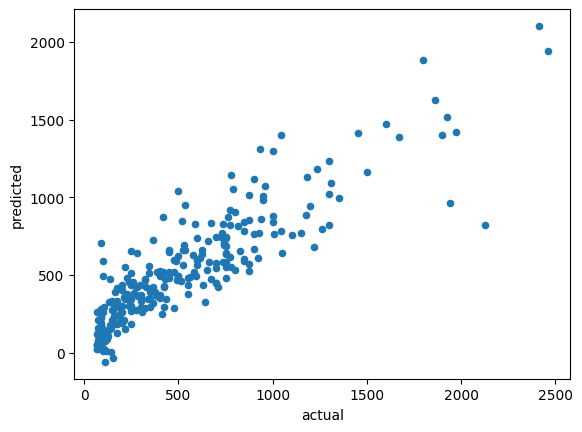

In [163]:
target.plot.scatter(x = "actual", y = "predicted")

The result of fitting the best elastic pipeline on the entire data set is that we get an optimal alpha of 10 and ratio of 1. It also gave us by far the best MSE of 86325.51. Looking at the plot we can see that the model is pretty good at predicting salary since we see a linear relationship between the actual and predicted values of salary.